## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/Delhi Accident Data.csv")
df.head()
df.columns = df.columns.str.strip()

## 3. Dataset Understanding

Instead of jumping into cleaning, first understand the dataset


In [3]:
df.shape

(75748, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75748 entries, 0 to 75747
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              75748 non-null  int64  
 1   DISTRICT          75748 non-null  str    
 2   VEHICLE AT FAULT  75748 non-null  str    
 3   VICTIM            75748 non-null  str    
 4   TYPE OF ACCIDENT  75748 non-null  str    
 5   # INJURED         75748 non-null  int64  
 6   # KILLED          75748 non-null  int64  
 7   Unnamed: 7        0 non-null      float64
 8   Unnamed: 8        0 non-null      float64
 9   Unnamed: 9        1 non-null      str    
dtypes: float64(2), int64(3), str(5)
memory usage: 5.8 MB


In [5]:
df.describe()

,YEAR,# INJURED,# KILLED,Unnamed: 7,Unnamed: 8
count,75748.000000,75748.000000,75748.000000,0.0,0.0
mean,2012.446863,0.955682,0.248640,NaN,NaN
std,2.868879,0.840229,0.450093,NaN,NaN
min,2008.000000,0.000000,0.000000,NaN,NaN
25%,2010.000000,1.000000,0.000000,NaN,NaN
50%,2013.000000,1.000000,0.000000,NaN,NaN
75%,2015.000000,1.000000,0.000000,NaN,NaN
max,2017.000000,30.000000,6.000000,NaN,NaN


In [6]:
df.columns

Index(['YEAR', 'DISTRICT', 'VEHICLE AT FAULT', 'VICTIM', 'TYPE OF ACCIDENT',
       '# INJURED', '# KILLED', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9'],
      dtype='str')

In [7]:
df.isnull().sum()

YEAR                    0
DISTRICT                0
VEHICLE AT FAULT        0
VICTIM                  0
TYPE OF ACCIDENT        0
# INJURED               0
# KILLED                0
Unnamed: 7          75748
Unnamed: 8          75748
Unnamed: 9          75747
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(56818)

## 4. Data Cleaning

In [9]:
df = df.drop(columns=[
    "Unnamed: 7",
    "Unnamed: 8",
    "Unnamed: 9"
])

In [10]:
df.head()

,YEAR,DISTRICT,VEHICLE AT FAULT,VICTIM,TYPE OF ACCIDENT,# INJURED,# KILLED
0,2008,NORTH WEST DELHI,UNKNOWN,CAR,FATAL ACCIDENT,0,1
1,2008,NORTH WEST DELHI,UNKNOWN,CYCLE,SIMPLE ACCIDENT,1,0
2,2008,NEW DELHI,HTV/GDS,PEDESTRIAN,FATAL ACCIDENT,0,1
3,2008,EAST DELHI,S/C&M/C,PEDESTRIAN,SIMPLE ACCIDENT,1,0
4,2008,SHAHDARA,S/C&M/C,PEDESTRIAN,SIMPLE ACCIDENT,1,0


In [11]:
df.shape

(75748, 7)

In [12]:
df.isnull().sum()

YEAR                0
DISTRICT            0
VEHICLE AT FAULT    0
VICTIM              0
TYPE OF ACCIDENT    0
# INJURED           0
# KILLED            0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(56819)

## 5. Exploratory Data Analysis (EDA)

In [14]:
## Number of Accidents by Year
df["YEAR"].value_counts().sort_index()

YEAR
2008    8435
2009    7515
2010    7259
2011    7280
2012    6937
2013    7566
2014    8623
2015    8085
2016    7375
2017    6673
Name: count, dtype: int64

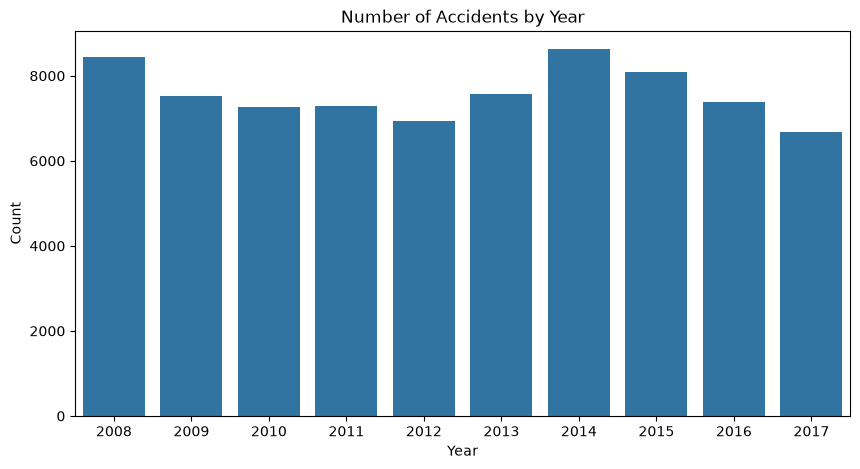

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="YEAR"
)

plt.title("Number of Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

### Observation

This graph shows the distribution of accident records across different years.
It helps identify whether accidents increased or decreased over time.


In [16]:
## Accidents by district
df["DISTRICT"].value_counts()

DISTRICT
SOUTH EAST DELHI       10096
NEW DELHI               9529
NORTH DELHI(ROHINI)     8903
CENTRAL DELHI           8119
SOUTH WEST DELHI        7462
WEST DELHI              7289
NORTH WEST DELHI        7013
EAST DELHI              5599
SHAHDARA                4850
SOUTH DELHI             3716
NORTH EAST DELHI        3153
UNK                       18
OUTER                      1
Name: count, dtype: int64

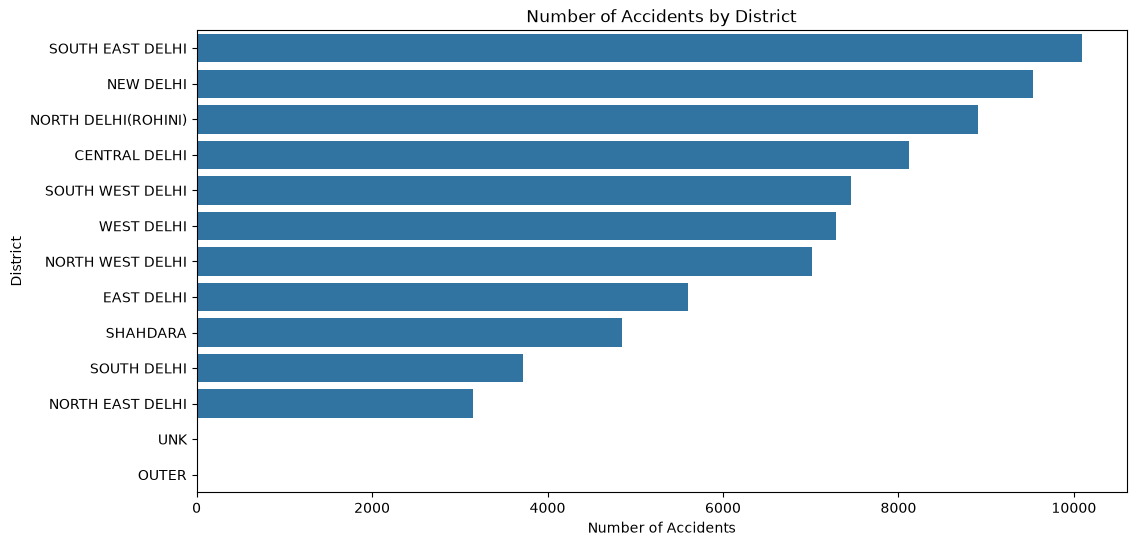

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="DISTRICT",
    order=df["DISTRICT"].value_counts().index
)

plt.title("Number of Accidents by District")
plt.xlabel("Number of Accidents")
plt.ylabel("District")

plt.show()

### Observation

This graph identifies districts with the highest and lowest number of recorded accidents.

In [18]:
## Vehical at fault
df["VEHICLE AT FAULT"].value_counts()

VEHICLE AT FAULT
PVT CAR              22043
UNKNOWN              19145
S/C&M/C              10990
HTV/GDS               6029
TEMPO                 4369
TSR                   2006
DTC BUS               1879
BUS OTR               1241
TAXI                  1226
DELIVERY VAN          1090
BLUE LN                981
MIN.BUS                969
GRM.SEW                756
TRACTOR                664
TANKER                 482
TRAILER/CONTAINER      383
BUS O S                339
CTR BUS                268
CRANE                  263
DELIVRY                107
BUS SCL                100
ERCAW                  100
CAL CAB                 79
TRL/CON                 70
MILITRY                 54
AMBULNC                 44
POL.VEH                 23
C.RICKW                 17
STEEM R                 13
TONGA/R                  4
MATADOR                  4
B.CARTS                  4
HANDCRT                  3
CYCLELIST                3
Name: count, dtype: int64

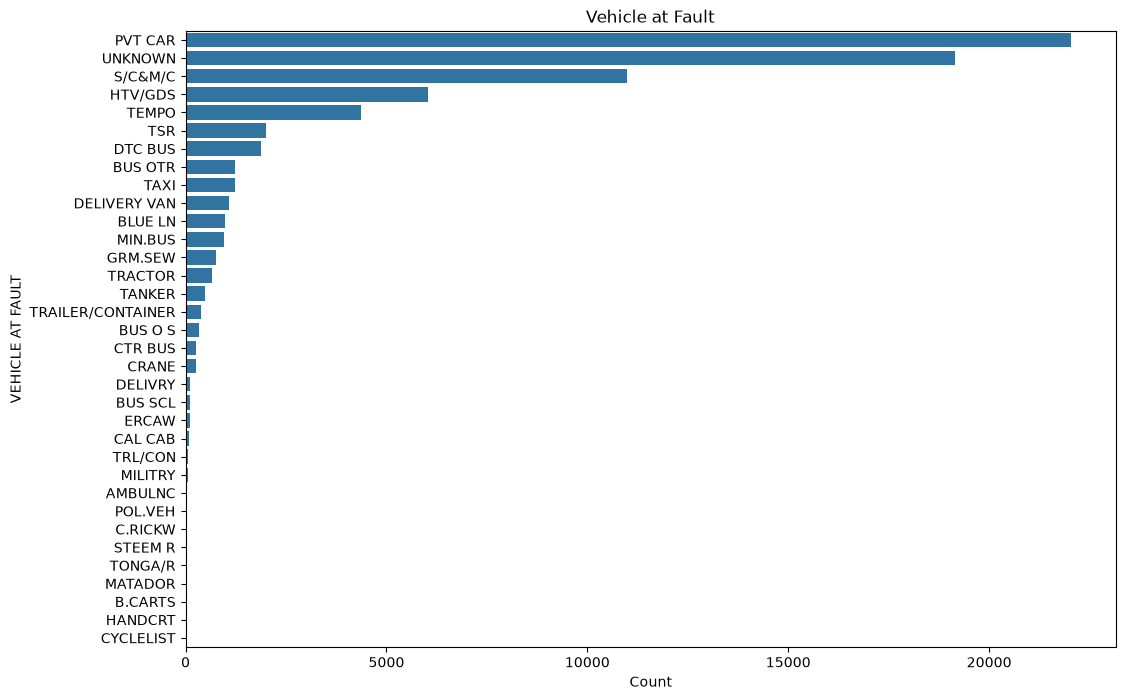

In [19]:
plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    y="VEHICLE AT FAULT",
    order=df["VEHICLE AT FAULT"].value_counts().index
)

plt.title("Vehicle at Fault")
plt.xlabel("Count")

plt.show()

In [20]:
## Victim Type
df["VICTIM"].value_counts()

VICTIM
PEDESTRIAN        31872
S/C & M/C         26280
CAR                4238
CYCLE              3349
SELF               2918
TSR                2026
CYCLE RICKSHAW     1404
PASSANGER           927
TEMPO               480
DELIVERY VAN        420
HTV                 290
TAXI                264
TNG                 201
ERC                 167
DTC                 132
POLICE VEHICLE      103
HDC                  98
GMS                  78
TMP                  74
BUS                  63
TRC                  62
MINI BUS/RTV         48
TCN                  39
TNK                  29
AMBULANCE            24
TAX                  23
BLB                  19
BUL                  16
OSB                  15
CRN                  13
MAT                  12
ANI                  11
CBS                  10
MBS                   9
POV                   9
SBS                   7
MIL                   7
EBK                   5
CAB                   4
STR                   1
ELT                   1
Name: cou

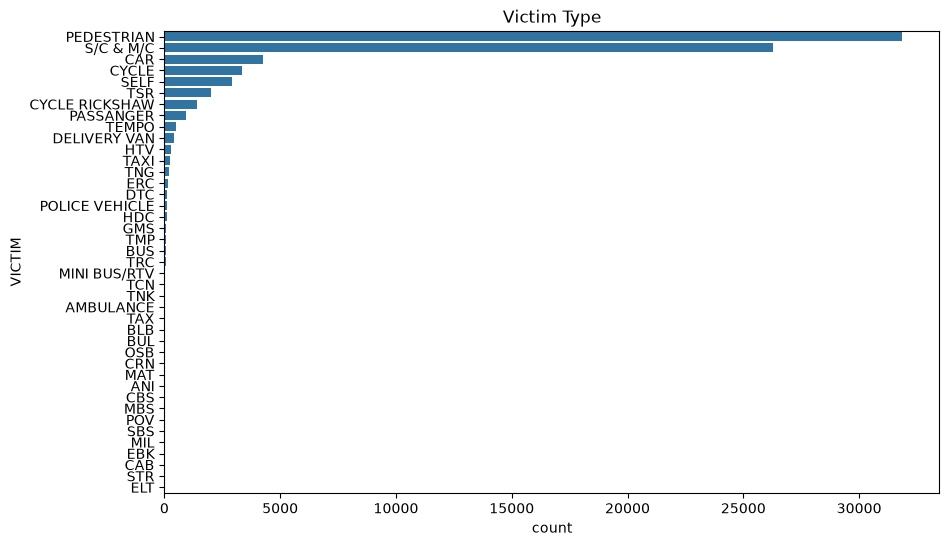

In [21]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="VICTIM",
    order=df["VICTIM"].value_counts().index
)

plt.title("Victim Type")

plt.show()

In [22]:
## Type of accidents
df["TYPE OF ACCIDENT"].value_counts()

TYPE OF ACCIDENT
SIMPLE ACCIDENT    55883
FATAL ACCIDENT     18361
NON INJURY          1504
Name: count, dtype: int64

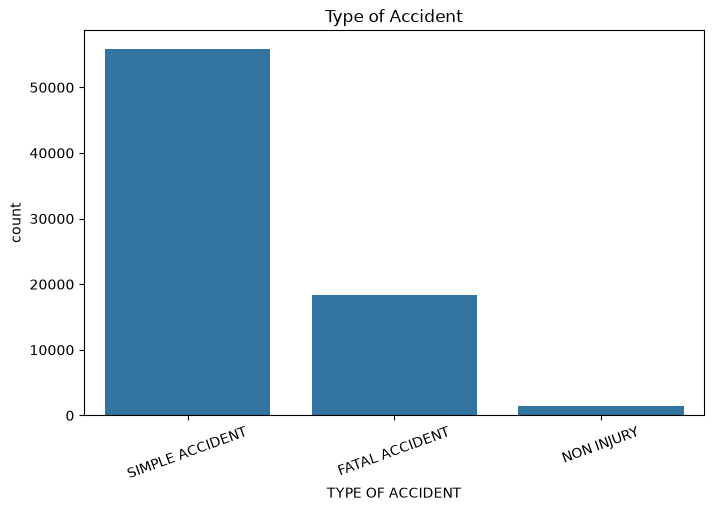

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TYPE OF ACCIDENT",
    order=df["TYPE OF ACCIDENT"].value_counts().index
)

plt.xticks(rotation=20)

plt.title("Type of Accident")

plt.show()

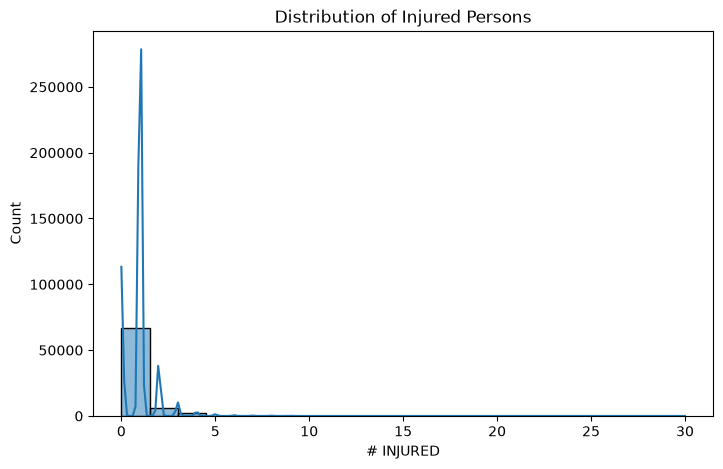

In [24]:
## Distribution of injured
plt.figure(figsize=(8,5))

sns.histplot(
    df["# INJURED"],
    bins=20,
    kde=True
)

plt.title("Distribution of Injured Persons")

plt.show()

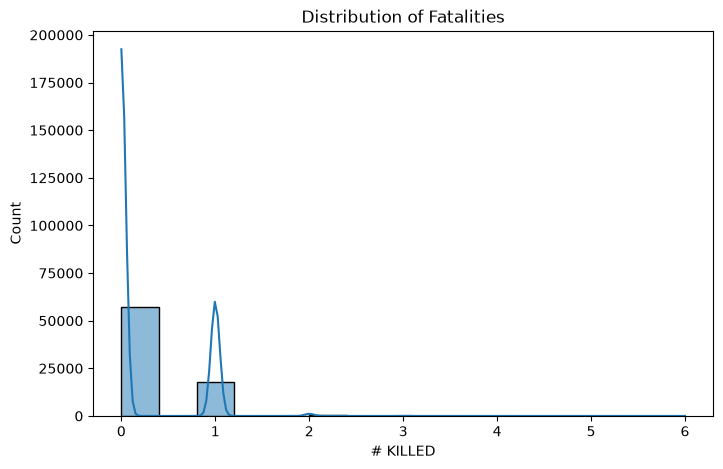

In [25]:
## Distribution of deaths
plt.figure(figsize=(8,5))

sns.histplot(
    df["# KILLED"],
    bins=15,
    kde=True
)

plt.title("Distribution of Fatalities")

plt.show()

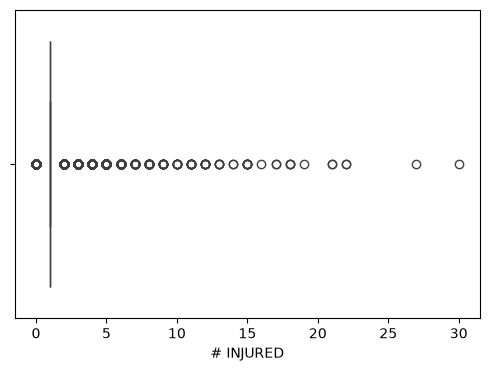

In [26]:
## outlier detection 
## injured
plt.figure(figsize=(6,4))

sns.boxplot(
    x=df["# INJURED"]
)

plt.show()

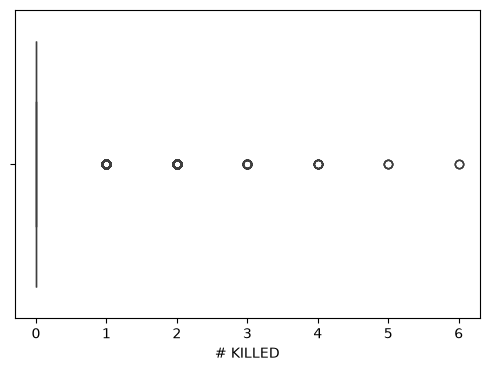

In [27]:
##killed
plt.figure(figsize=(6,4))

sns.boxplot(
    x=df["# KILLED"]
)

plt.show()

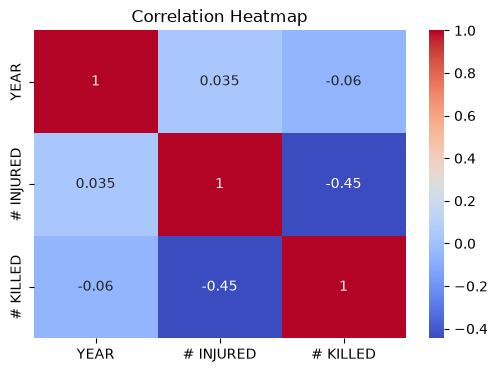

In [28]:
## Correlation Matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The numerical features show weak correlations with each other.
The number of injured and the number of killed have a moderate negative correlation (-0.45), while the year has almost no correlation with either variable.

## 6. Feature Engineering

In [29]:
'''
Define Features and Target

Target (y):

INJURED

Features (X):

YEAR
DISTRICT
VEHICLE AT FAULT
VICTIM
TYPE OF ACCIDENT
                    '''

'\nDefine Features and Target\n\nTarget (y):\n\nINJURED\n\nFeatures (X):\n\nYEAR\nDISTRICT\nVEHICLE AT FAULT\nVICTIM\nTYPE OF ACCIDENT\n                    '

In [30]:
#Separate Features and Target
X = df.drop(columns=["# INJURED", "# KILLED"])
y = df["# INJURED"]
print(X.head())
print(y.head())

   YEAR          DISTRICT VEHICLE AT FAULT      VICTIM TYPE OF ACCIDENT
0  2008  NORTH WEST DELHI          UNKNOWN         CAR   FATAL ACCIDENT
1  2008  NORTH WEST DELHI          UNKNOWN       CYCLE  SIMPLE ACCIDENT
2  2008         NEW DELHI          HTV/GDS  PEDESTRIAN   FATAL ACCIDENT
3  2008        EAST DELHI          S/C&M/C  PEDESTRIAN  SIMPLE ACCIDENT
4  2008          SHAHDARA          S/C&M/C  PEDESTRIAN  SIMPLE ACCIDENT
0    0
1    1
2    0
3    1
4    1
Name: # INJURED, dtype: int64


In [31]:
#Encoding categorical columns
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()

In [32]:
categorical_columns=[
    "DISTRICT",
    "VEHICLE AT FAULT",
    "VICTIM",
    "TYPE OF ACCIDENT"
]
for column in categorical_columns:
    X[column]=le.fit_transform(X[column])

In [33]:
X.head()

,YEAR,DISTRICT,VEHICLE AT FAULT,VICTIM,TYPE OF ACCIDENT
0,2008,5,33,6,0
1,2008,5,33,9,2
2,2008,2,17,25,0
3,2008,1,23,25,2
4,2008,7,23,25,2


In [34]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60598, 5)
(15150, 5)
(60598,)
(15150,)


In [36]:
## Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
print(X_train[:5])

[[-1.54801696 -0.38277248 -0.27212864  0.06832744  0.58903193]
 [ 1.23771482 -0.63861558 -0.27212864  0.06832744  0.58903193]
 [ 0.54128187  1.1522861   1.23872802  0.49257412  0.58903193]
 [ 1.23771482 -0.12692938  1.23872802  0.49257412  0.58903193]
 [-1.19980049 -0.63861558  1.23872802  0.06832744 -1.74338595]]


# 7: Model Training (Linear Regression)



In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.01,-0.02,-0.05, 0.01, 0.41]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.9545
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[258.03,254.62,246.3 ,240.21,230.68]"


# 8: Model Prediction


In [39]:
y_pred = model.predict(X_test)

In [40]:
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_df.head()

,Actual,Predicted
0,1,1.254723
1,0,0.167549
2,1,1.240404
3,0,0.249855
4,0,0.233501


# 9: Model Evaluation



In [41]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.3767517884368105
Mean Squared Error (MSE): 0.5990745792022105
Root Mean Squared Error (RMSE): 0.7739990821714264
R² Score: 0.23880409677277514


In [42]:
'''
Metric	Your Value	Interpretation
MAE	0.3768	On average, the model's prediction differs from the actual number of injured people by about 0.38.
MSE	0.5991	The average squared error is 0.5991. Lower is better.
RMSE	0.7740	The typical prediction error is about 0.77 injured persons.
R² Score	0.2388	The model explains about 23.9% of the variation in the number of injured people.
'''

"\nMetric\tYour Value\tInterpretation\nMAE\t0.3768\tOn average, the model's prediction differs from the actual number of injured people by about 0.38.\nMSE\t0.5991\tThe average squared error is 0.5991. Lower is better.\nRMSE\t0.7740\tThe typical prediction error is about 0.77 injured persons.\nR² Score\t0.2388\tThe model explains about 23.9% of the variation in the number of injured people.\n"

# 10: Conclusion

The Linear Regression model was successfully trained and evaluated on the accident dataset.

### Results
- Mean Absolute Error (MAE): 0.3768
- Mean Squared Error (MSE): 0.5991
- Root Mean Squared Error (RMSE): 0.7740
- R² Score: 0.2388

### Interpretation

The model achieved an R² score of approximately 0.24, indicating that it explains about 24% of the variation in the number of injured people. This suggests that the Linear Regression model provides only a moderate fit for this dataset. The relatively low R² score indicates that additional features or more advanced machine learning models may improve prediction accuracy.

#  11: Decision Tree Regression


In [49]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

# 12: Decision Tree Prediction

The trained Decision Tree Regression model is used to predict the number of injured people for the test dataset. These predictions are compared with the actual values to evaluate the model's performance.

In [50]:
dt_pred = dt_model.predict(X_test)

In [51]:
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Decision Tree Prediction": dt_pred
})

prediction_df.head()

,Actual,Decision Tree Prediction
0,1,1.235258
1,0,0.047217
2,1,1.235258
3,0,0.265956
4,0,0.265956


#  13: Decision Tree Evaluation


In [52]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regression Results")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Regression Results
MAE : 0.3448238910050723
MSE : 0.5449644045374512
RMSE: 0.7382170443287335
R² Score: 0.3075575453543776


#  14: Decision Tree Conclusion

The Decision Tree Regression model was trained using a maximum tree depth of 5 to reduce overfitting and improve generalization.

### Results

- Mean Absolute Error (MAE): 0.3448
- Mean Squared Error (MSE): 0.5450
- Root Mean Squared Error (RMSE): 0.7382
- R² Score: 0.3076

### Interpretation

The tuned Decision Tree Regression model outperformed the Linear Regression model across all evaluation metrics. Limiting the tree depth helped reduce overfitting, resulting in better prediction accuracy and a higher R² score. At this stage, the Decision Tree Regression model is the best-performing model for this dataset.